In [ ]:
 import pandas as pd
 import seaborn as sns
 import matplotlib.pyplot as plt
 import numpy as np
 import warnings
 warnings.filterwarnings("ignore")
 import plotly.express as px

In [ ]:
df = pd.read_csv("/content/covid.csv")
df.head()

,Province/State,Country/Region,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
0,NaN,Afghanistan,33.93911,67.709953,2020-01-22,0,0,0,0,Eastern Mediterranean
1,NaN,Albania,41.15330,20.168300,2020-01-22,0,0,0,0,Europe
2,NaN,Algeria,28.03390,1.659600,2020-01-22,0,0,0,0,Africa
3,NaN,Andorra,42.50630,1.521800,2020-01-22,0,0,0,0,Europe
4,NaN,Angola,-11.20270,17.873900,2020-01-22,0,0,0,0,Africa


In [ ]:
df.info() # so we are having 31890 rows and we are

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49068 entries, 0 to 49067
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Province/State  14664 non-null  object 
 1   Country/Region  49068 non-null  object 
 2   Lat             49068 non-null  float64
 3   Long            49068 non-null  float64
 4   Date            49068 non-null  object 
 5   Confirmed       49068 non-null  int64  
 6   Deaths          49068 non-null  int64  
 7   Recovered       49068 non-null  int64  
 8   Active          49068 non-null  int64  
 9   WHO Region      49068 non-null  object 
dtypes: float64(2), int64(4), object(4)
memory usage: 3.7+ MB


In [ ]:
# Active is the target column and the rest of them are the independent columns

#province/state: the specific state orprovince within a country
#country/region: the naoe of country wheter the covid-19 cases were suspected
#long and lat: of the country
#date :  date on which the data was recorded
#confirmed : the number of confimred cases of covid 19
#deaths : the number of people who died due to covid 19
#recovered : the number of people who recover from the covid 19
#active: number of active cases
#who region : the who who covers the specific region

In [ ]:
#use the rename function and rename the province/state columns as state and country/region as country
# also get the count of all the data in the date columns and also find the min and max date

In [ ]:
df.rename(columns={"Province/State":"State"},inplace=True)

In [ ]:
df.rename(columns={"Country/Region":"Country"},inplace=True)

In [ ]:
df['Date'].value_counts()

,count
Date,
2020-01-22,261
2020-01-23,261
2020-01-24,261
2020-01-25,261
2020-01-26,261
...,...
2020-07-23,261
2020-07-24,261
2020-07-25,261


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49068 entries, 0 to 49067
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   State       14664 non-null  object 
 1   Country     49068 non-null  object 
 2   Lat         49068 non-null  float64
 3   Long        49068 non-null  float64
 4   Date        49068 non-null  object 
 5   Confirmed   49068 non-null  int64  
 6   Deaths      49068 non-null  int64  
 7   Recovered   49068 non-null  int64  
 8   Active      49068 non-null  int64  
 9   WHO Region  49068 non-null  object 
dtypes: float64(2), int64(4), object(4)
memory usage: 3.7+ MB


In [ ]:
df['Date'] = pd.to_datetime(df['Date'])

In [ ]:
df['Date'].min()

Timestamp('2020-01-22 00:00:00')

In [ ]:
df['Date'].max()

Timestamp('2020-07-27 00:00:00')

Q) Q) seelect all the confirmed cases with respect to data and store it in a  new dataframe
#and creae a line plot and

In [ ]:
new_df = df.groupby("Date")['Confirmed'].sum().reset_index()
new_df # withthe help of reset_index we will convert it into the dataframe otherwise it will return the output in the Series format

,Date,Confirmed
0,2020-01-22,555
1,2020-01-23,654
2,2020-01-24,941
3,2020-01-25,1434
4,2020-01-26,2118
...,...,...
183,2020-07-23,15510481
184,2020-07-24,15791645
185,2020-07-25,16047190
186,2020-07-26,16251796


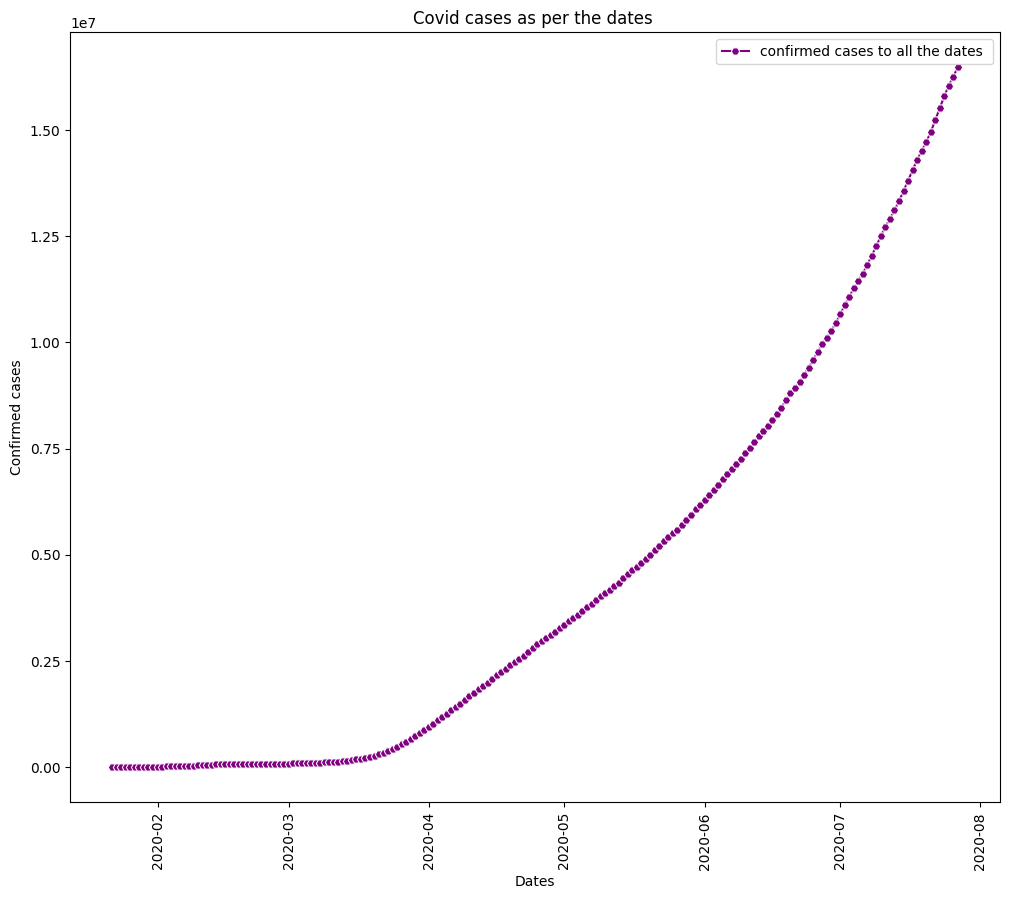

In [ ]:
plt.figure(figsize=(12,10))
sns.lineplot(data=new_df,x='Date',y='Confirmed',label='confirmed cases to all the dates ',color='purple',marker='H')
plt.xlabel("Dates")
plt.ylabel("Confirmed cases")
plt.title("Covid cases as per the dates ")
plt.legend(loc='best')
plt.xticks(rotation=90)
plt.show()


In [ ]:
death = df.groupby("Date")['Deaths'].sum().reset_index()

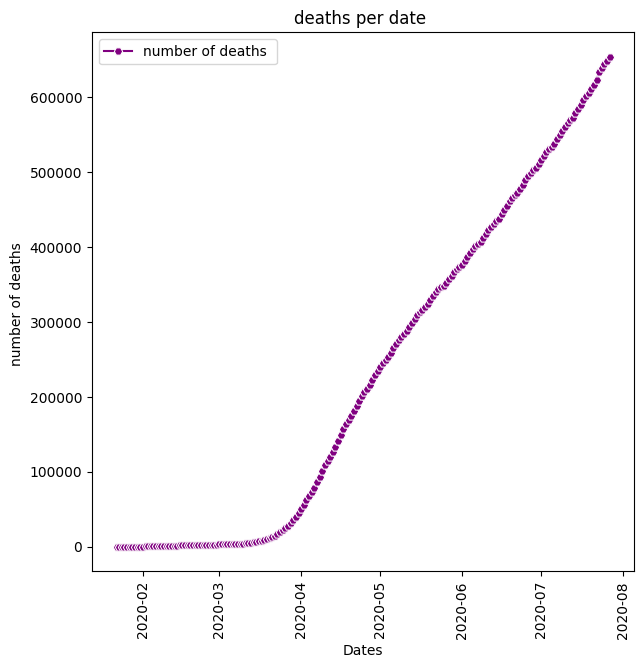

In [ ]:
plt.figure(figsize=(7,7))
sns.lineplot(data=death,x='Date',y='Deaths',label='number of deaths ',color='purple',marker='H')
plt.xlabel("Dates")
plt.ylabel("number of deaths ")
plt.title("deaths per date ")
plt.legend(loc='best')
plt.xticks(rotation=90)
plt.show()

In [ ]:
new = df.groupby(['Date'])[['Deaths','Active','Recovered']].sum().reset_index()
new

,Date,Deaths,Active,Recovered
0,2020-01-22,17,510,28
1,2020-01-23,18,606,30
2,2020-01-24,26,879,36
3,2020-01-25,42,1353,39
4,2020-01-26,56,2010,52
...,...,...,...,...
183,2020-07-23,633506,6166006,8710969
184,2020-07-24,639650,6212290,8939705
185,2020-07-25,644517,6243930,9158743
186,2020-07-26,648621,6309711,9293464


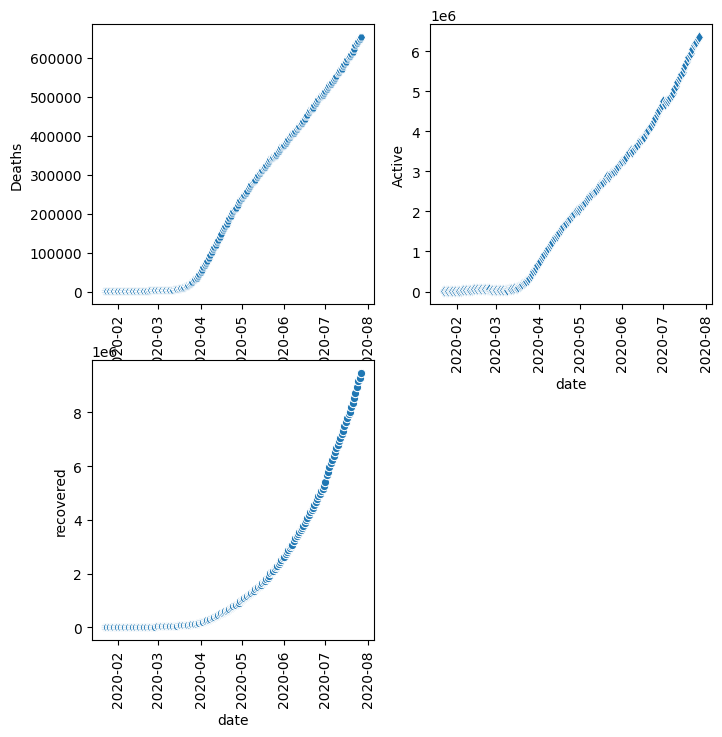

In [ ]:
plt.figure(figsize=(8,8))
plt.subplot(2,2,1)
sns.lineplot(data=new,x='Date',y='Deaths',marker='H')
plt.xlabel("date")
plt.ylabel("Deaths")
plt.xticks(rotation=90)
plt.subplot(2,2,2)
sns.lineplot(data=new,x='Date',y='Active',marker='d')
plt.xlabel("date")
plt.xticks(rotation=90)
plt.ylabel("Active")
plt.subplot(2,2,3)
sns.lineplot(data=new,x='Date',y='Recovered',marker='o')
plt.xlabel("date")
plt.ylabel("recovered")
plt.xticks(rotation=90)
plt.show()

In [ ]:
# Q) randomly selecting 3 countries :india,us,china
# Q) create 3 new dataframes for all these countries
# Q) and then select the confirmed cases active cases, deaths with respect to date

In [ ]:
india = df[df['Country']=='India']
india # so we are getting 188 rows where the country is indian

,State,Country,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
129,NaN,India,20.593684,78.96288,2020-01-22,0,0,0,0,South-East Asia
390,NaN,India,20.593684,78.96288,2020-01-23,0,0,0,0,South-East Asia
651,NaN,India,20.593684,78.96288,2020-01-24,0,0,0,0,South-East Asia
912,NaN,India,20.593684,78.96288,2020-01-25,0,0,0,0,South-East Asia
1173,NaN,India,20.593684,78.96288,2020-01-26,0,0,0,0,South-East Asia
...,...,...,...,...,...,...,...,...,...,...
47892,NaN,India,20.593684,78.96288,2020-07-23,1288108,30601,817209,440298,South-East Asia
48153,NaN,India,20.593684,78.96288,2020-07-24,1337024,31358,849432,456234,South-East Asia
48414,NaN,India,20.593684,78.96288,2020-07-25,1385635,32060,885573,468002,South-East Asia
48675,NaN,India,20.593684,78.96288,2020-07-26,1435616,32771,917568,485277,South-East Asia


In [ ]:
ind_new = india.groupby(['Date'])[['Deaths','Active','Confirmed','Recovered']].sum().reset_index()
ind_new

,Date,Deaths,Active,Confirmed,Recovered
0,2020-01-22,0,0,0,0
1,2020-01-23,0,0,0,0
2,2020-01-24,0,0,0,0
3,2020-01-25,0,0,0,0
4,2020-01-26,0,0,0,0
...,...,...,...,...,...
183,2020-07-23,30601,440298,1288108,817209
184,2020-07-24,31358,456234,1337024,849432
185,2020-07-25,32060,468002,1385635,885573
186,2020-07-26,32771,485277,1435616,917568


In [ ]:
china = df[df['Country']=='China'] # 6204 is the number of rows which is having the data of china
new_china = china.groupby(['Date'])[['Confirmed','Deaths','Recovered','Active']].sum().reset_index()
new_china

,Date,Confirmed,Deaths,Recovered,Active
0,2020-01-22,548,17,28,503
1,2020-01-23,643,18,30,595
2,2020-01-24,920,26,36,858
3,2020-01-25,1406,42,39,1325
4,2020-01-26,2075,56,49,1970
...,...,...,...,...,...
183,2020-07-23,86045,4649,78701,2695
184,2020-07-24,86202,4650,78745,2807
185,2020-07-25,86381,4652,78813,2916
186,2020-07-26,86570,4652,78862,3056


In [ ]:
US = df[df['Country']=='US']
new_us = US.groupby(['Date'])[['Active','Recovered','Deaths','Confirmed']].sum().reset_index()
new_us

,Date,Active,Recovered,Deaths,Confirmed
0,2020-01-22,1,0,0,1
1,2020-01-23,1,0,0,1
2,2020-01-24,2,0,0,2
3,2020-01-25,2,0,0,2
4,2020-01-26,5,0,0,5
...,...,...,...,...,...
183,2020-07-23,2661117,1233269,144430,4038816
184,2020-07-24,2705347,1261624,145560,4112531
185,2020-07-25,2753091,1279414,146465,4178970
186,2020-07-26,2789125,1297863,146935,4233923


#pointplot is the same like line plot but it will point the plots in the dotted format

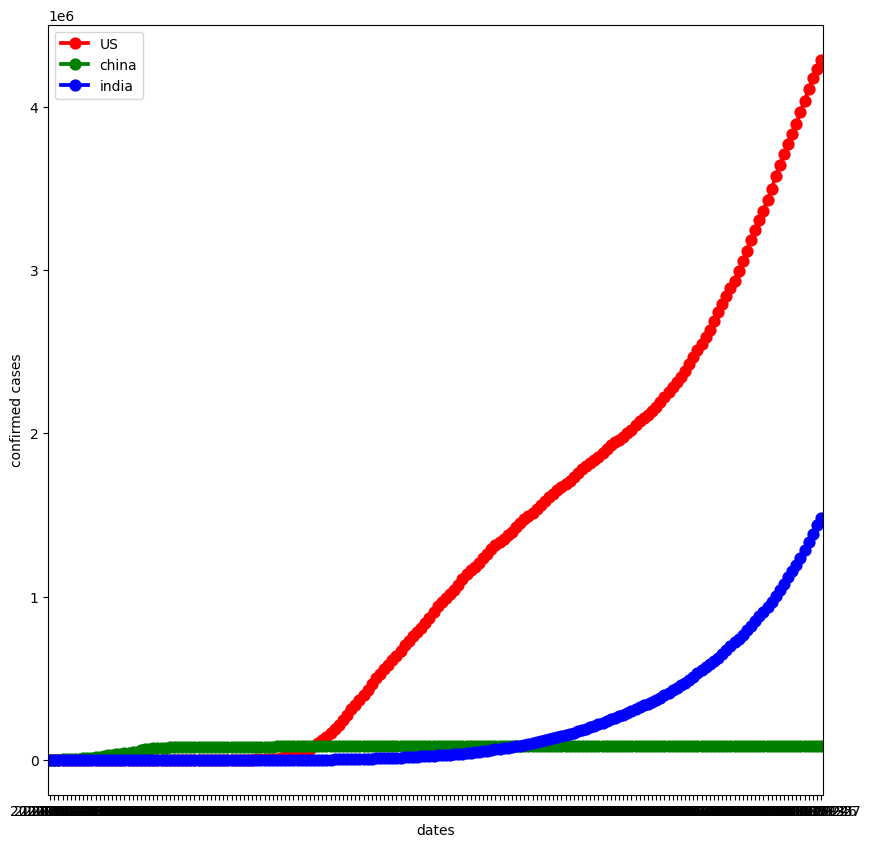

In [ ]:
plt.figure(figsize=(10,10))
sns.pointplot(data=new_us,x='Date',y='Confirmed',color='red',label='US')
sns.pointplot(data=new_china,x='Date',y='Confirmed',color='green',label='china')
sns.pointplot(data=ind_new,x='Date',y='Confirmed',color='blue',label='india')
plt.xlabel("dates")
plt.ylabel("confirmed cases")
plt.legend(loc='best')
plt.show()

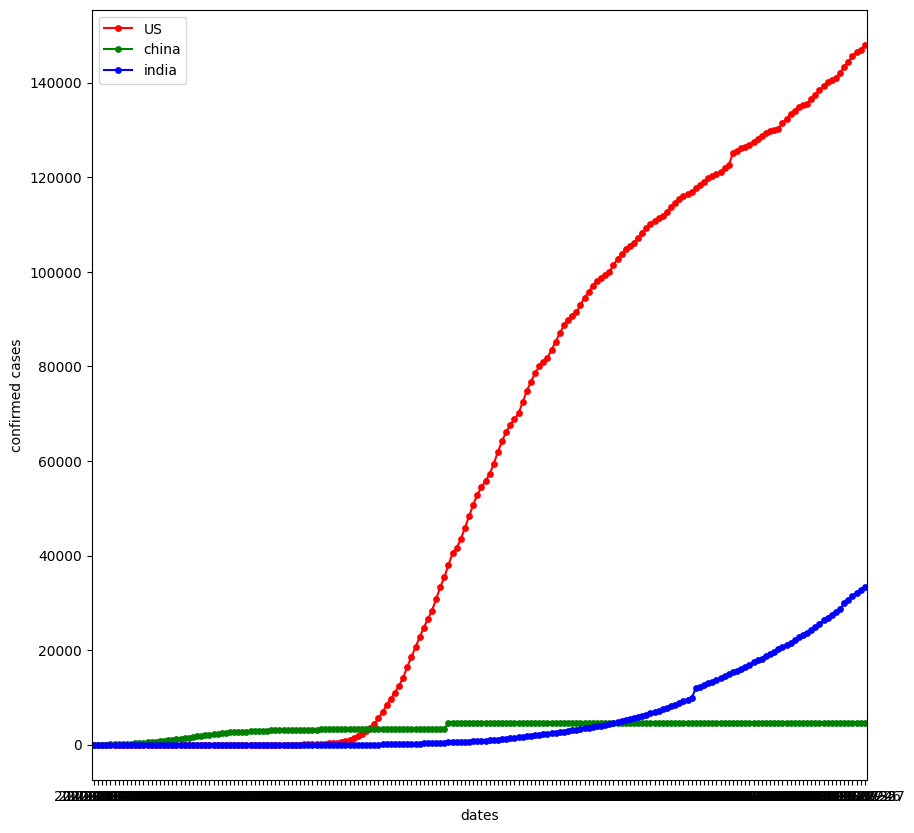

In [ ]:
# Q) create a point plot for the number of deaths from the following 3 countries
plt.figure(figsize=(10,10))
sns.pointplot(data=new_us,x='Date',y='Deaths',color='red',label='US',linewidth=1.5)
sns.pointplot(data=new_china,x='Date',y='Deaths',color='green',label='china',linewidth=1.5)
sns.pointplot(data=ind_new,x='Date',y='Deaths',color='blue',label='india',linewidth=1.5)
plt.xlabel("dates")
plt.ylabel("confirmed cases")
plt.legend(loc='best')
plt.show()

#model building

#prophet is the new time series forecasting tool that was developed by facebook

#prophet is a time series forcasting tool developed via facebook that desiigned tobe easy to use and effective for a wide range of time series data its particularly useful data that has strong seasonal effects like daily or weekly patterns and include important dates or events that can impact forecast

#difference between ARIMA and other versus prophet model is like ⁉
# arima needs to do remove the seasonality or the trend from teh data and in thesse to be done manually
# but in the prophet model we do not need to doit manually it willbe done by the model

In [ ]:
# formual for prohet
# y(T) = g(T)+s(T)+h(T)+Et
# y(T)is the "Trend"
# G(T) is the seasonality
# h(T) is the holidays/events
# E(T) is the error term

In [ ]:
!pip install prophet

In [ ]:
from prophet import Prophet

#prophet is the algorithmwhich also uses the concept of like it will also have "Two columns only "
# ds :date (columns)
# y : Target columns
# so  we need to convert them as the columns name of "ds,y" only it is mandatory

In [ ]:
confirmed_cases = df.groupby(['Date'])['Confirmed'].sum().reset_index()
confirmed_cases

,Date,Confirmed
0,2020-01-22,555
1,2020-01-23,654
2,2020-01-24,941
3,2020-01-25,1434
4,2020-01-26,2118
...,...,...
183,2020-07-23,15510481
184,2020-07-24,15791645
185,2020-07-25,16047190
186,2020-07-26,16251796


In [ ]:
confirmed_cases.columns = ['ds','y'] # doing this step is mandatory

In [ ]:
model = Prophet()
model.fit(confirmed_cases)

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [ ]:
future_pred = model.make_future_dataframe(periods=7) # everyday data so we have pass the periods to be consider as the 7 weekly period
forcasted = model.predict(future_pred) # predicting hte future values
forcasted

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2020-01-22,-9.613288e+03,-1.318154e+05,9.222432e+04,-9.613288e+03,-9.613288e+03,-11063.558307,-11063.558307,-11063.558307,-11063.558307,-11063.558307,-11063.558307,0.0,0.0,0.0,-2.067685e+04
1,2020-01-23,-6.933409e+03,-1.048362e+05,1.017946e+05,-6.933409e+03,-6.933409e+03,-1117.543863,-1117.543863,-1117.543863,-1117.543863,-1117.543863,-1117.543863,0.0,0.0,0.0,-8.050953e+03
2,2020-01-24,-4.253530e+03,-1.050040e+05,1.105377e+05,-4.253530e+03,-4.253530e+03,10080.978737,10080.978737,10080.978737,10080.978737,10080.978737,10080.978737,0.0,0.0,0.0,5.827449e+03
3,2020-01-25,-1.573651e+03,-9.904187e+04,1.247526e+05,-1.573651e+03,-1.573651e+03,13750.326871,13750.326871,13750.326871,13750.326871,13750.326871,13750.326871,0.0,0.0,0.0,1.217668e+04
4,2020-01-26,1.106228e+03,-9.821111e+04,1.153278e+05,1.106228e+03,1.106228e+03,7298.791978,7298.791978,7298.791978,7298.791978,7298.791978,7298.791978,0.0,0.0,0.0,8.405020e+03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
190,2020-07-30,1.674503e+07,1.664167e+07,1.685059e+07,1.673981e+07,1.674994e+07,-1117.543863,-1117.543863,-1117.543863,-1117.543863,-1117.543863,-1117.543863,0.0,0.0,0.0,1.674392e+07
191,2020-07-31,1.694902e+07,1.685300e+07,1.706414e+07,1.693645e+07,1.695991e+07,10080.978737,10080.978737,10080.978737,10080.978737,10080.978737,10080.978737,0.0,0.0,0.0,1.695911e+07
192,2020-08-01,1.715301e+07,1.705859e+07,1.728062e+07,1.713212e+07,1.717032e+07,13750.326871,13750.326871,13750.326871,13750.326871,13750.326871,13750.326871,0.0,0.0,0.0,1.716677e+07
193,2020-08-02,1.735701e+07,1.725254e+07,1.746614e+07,1.732857e+07,1.738314e+07,7298.791978,7298.791978,7298.791978,7298.791978,7298.791978,7298.791978,0.0,0.0,0.0,1.736430e+07


#Ds : this columns contains the dates forwhich prediction have beeen made it stands for the "date stamp"
# yhat : thisis the predicted values (forcast) for the given date in the ds columns. It represents models best estimate for that point in time
# yhat upper : this columns represent the upper bound of the predicted values which indicates  the higher end of the confidence interval
# it suggests that the actual values is unlikely to exceed this amount,giving u an idea of the predictions uncertainty
# suppose: we havepredicted the value 250 and the yhat upper is 270 so that says that the value will not go beyond 270
#
#yhat lower: this columns represent the lower bound of hte predicted values. it suggests that the actual values is unlikely tobe lower then this amount

In [ ]:
forcasted

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2020-01-22,-9.613288e+03,-1.318154e+05,9.222432e+04,-9.613288e+03,-9.613288e+03,-11063.558307,-11063.558307,-11063.558307,-11063.558307,-11063.558307,-11063.558307,0.0,0.0,0.0,-2.067685e+04
1,2020-01-23,-6.933409e+03,-1.048362e+05,1.017946e+05,-6.933409e+03,-6.933409e+03,-1117.543863,-1117.543863,-1117.543863,-1117.543863,-1117.543863,-1117.543863,0.0,0.0,0.0,-8.050953e+03
2,2020-01-24,-4.253530e+03,-1.050040e+05,1.105377e+05,-4.253530e+03,-4.253530e+03,10080.978737,10080.978737,10080.978737,10080.978737,10080.978737,10080.978737,0.0,0.0,0.0,5.827449e+03
3,2020-01-25,-1.573651e+03,-9.904187e+04,1.247526e+05,-1.573651e+03,-1.573651e+03,13750.326871,13750.326871,13750.326871,13750.326871,13750.326871,13750.326871,0.0,0.0,0.0,1.217668e+04
4,2020-01-26,1.106228e+03,-9.821111e+04,1.153278e+05,1.106228e+03,1.106228e+03,7298.791978,7298.791978,7298.791978,7298.791978,7298.791978,7298.791978,0.0,0.0,0.0,8.405020e+03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
190,2020-07-30,1.674503e+07,1.664167e+07,1.685059e+07,1.673981e+07,1.674994e+07,-1117.543863,-1117.543863,-1117.543863,-1117.543863,-1117.543863,-1117.543863,0.0,0.0,0.0,1.674392e+07
191,2020-07-31,1.694902e+07,1.685300e+07,1.706414e+07,1.693645e+07,1.695991e+07,10080.978737,10080.978737,10080.978737,10080.978737,10080.978737,10080.978737,0.0,0.0,0.0,1.695911e+07
192,2020-08-01,1.715301e+07,1.705859e+07,1.728062e+07,1.713212e+07,1.717032e+07,13750.326871,13750.326871,13750.326871,13750.326871,13750.326871,13750.326871,0.0,0.0,0.0,1.716677e+07
193,2020-08-02,1.735701e+07,1.725254e+07,1.746614e+07,1.732857e+07,1.738314e+07,7298.791978,7298.791978,7298.791978,7298.791978,7298.791978,7298.791978,0.0,0.0,0.0,1.736430e+07


In [ ]:
forcasted = forcasted[['yhat_lower','yhat','yhat_upper']]

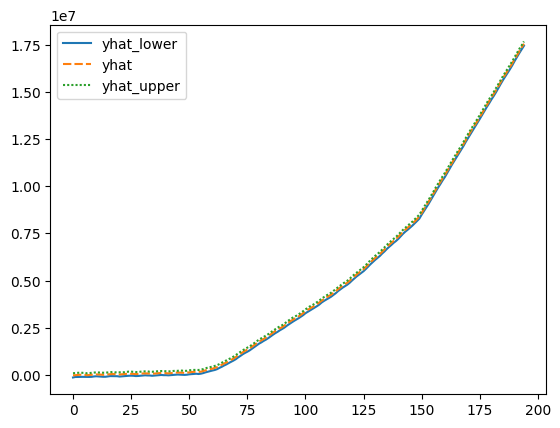

In [ ]:
sns.lineplot(forcasted)
plt.show()

In [ ]:
import plotly.express as  px
world = df.groupby(['Country'])[['Confirmed','Deaths','Active','Recovered']].sum().reset_index()
world.sort_values(by='Deaths',ascending=False)

,Country,Confirmed,Deaths,Active,Recovered
173,US,224345948,11011411,156981121,56353416
177,United Kingdom,26748587,3997775,22624595,126217
23,Brazil,89524967,3938034,31094060,54492873
85,Italy,26745145,3707717,7363518,15673910
61,France,21210926,3048524,10980287,7182115
...,...,...,...,...,...
141,Saint Lucia,2236,0,376,1860
148,Seychelles,3977,0,2730,1247
142,Saint Vincent and the Grenadines,2771,0,776,1995
168,Timor-Leste,2487,0,2487,0


In [ ]:
figure = px.choropleth(world,locations='Country',locationmode='country names',color='Active',hover_name = 'Country',range_color=[1,10000])
figure.show()

#whenever we want to visualize our geographcial data then we will use the "choropleth"
# world is the dataframe
# locations name of the countries is getting from here
# locationmode: like in the location columns how should the parameters should look like
#color='Active' so it would give us the active cases inthe data